In [15]:
import os
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint
import json

### Constants

In [17]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_dirname_output = './output'

Project: 20231010-gen-xii


### Output directory

In [18]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### List the variants

In [3]:
list_str_variant = [
    'model3',
    'model4',
    'model5',
    'model6',
]
list_str_model = [
    '01_ad',
    '02_pricing_pd',
    '03_pricing_lgd',
]

### Make a dictionary of important information

In [33]:
list_dict_row = []
# variants
for str_variant in tqdm(list_str_variant):
    # models
    for str_model in list_str_model:
        # get nfeats
        str_filename = 'df_cols_in_model.csv'
        str_uri = f's3://{str_project}/{str_model}/02_model/{str_variant}/02_model/01_lambda_get_starting_feats/{str_filename}'
        int_n_feats = len(list(pd.read_csv(str_uri)['feature']))
        
        # make dict row
        dict_row = {
            'Variant': str_variant,
            'Model': str_model,
            'N Features': int_n_feats,
        }
        
        # train, valid, and test scores
        str_summary_dir = f'0{str_variant[-1]}_{str_variant}'
        for str_df in ['train','valid','test']:
            str_filename = f'dict_eval_metrics_{str_df}.json'
            str_local_path = f'../../{str_model}/02_model/03_summary/{str_summary_dir}/output/{str_filename}'
            # open dictionary
            with open(str_local_path, 'r') as f:
                dict_metrics_train = json.load(f)
            # get the eval score
            if 'lgd' not in str_model:
                flt_score = dict_metrics_train['roc_auc']
            else:
                flt_score = dict_metrics_train['rmse']
            # assign
            dict_row[f'{str_df.capitalize()} Score'] = flt_score
        
        # append
        list_dict_row.append(dict_row)
        
# make df
df = pd.DataFrame(list_dict_row)
df

100%|██████████| 4/4 [00:00<00:00,  4.13it/s]


,Variant,Model,N Features,Train Score,Valid Score,Test Score
0,model3,01_ad,222,0.700238,0.703124,0.711536
1,model3,02_pricing_pd,139,0.855279,0.751054,0.718589
2,model3,03_pricing_lgd,173,0.247004,0.271451,0.273220
3,model4,01_ad,222,0.700238,0.703124,0.711536
4,model4,02_pricing_pd,158,0.857665,0.751291,0.714699
5,model4,03_pricing_lgd,219,0.240741,0.271256,0.273197
6,model5,01_ad,360,0.707035,0.702880,0.708856
7,model5,02_pricing_pd,299,0.897959,0.756160,0.709962
8,model5,03_pricing_lgd,211,0.241494,0.271148,0.274294
9,model6,01_ad,360,0.707035,0.702880,0.708856


### Plot

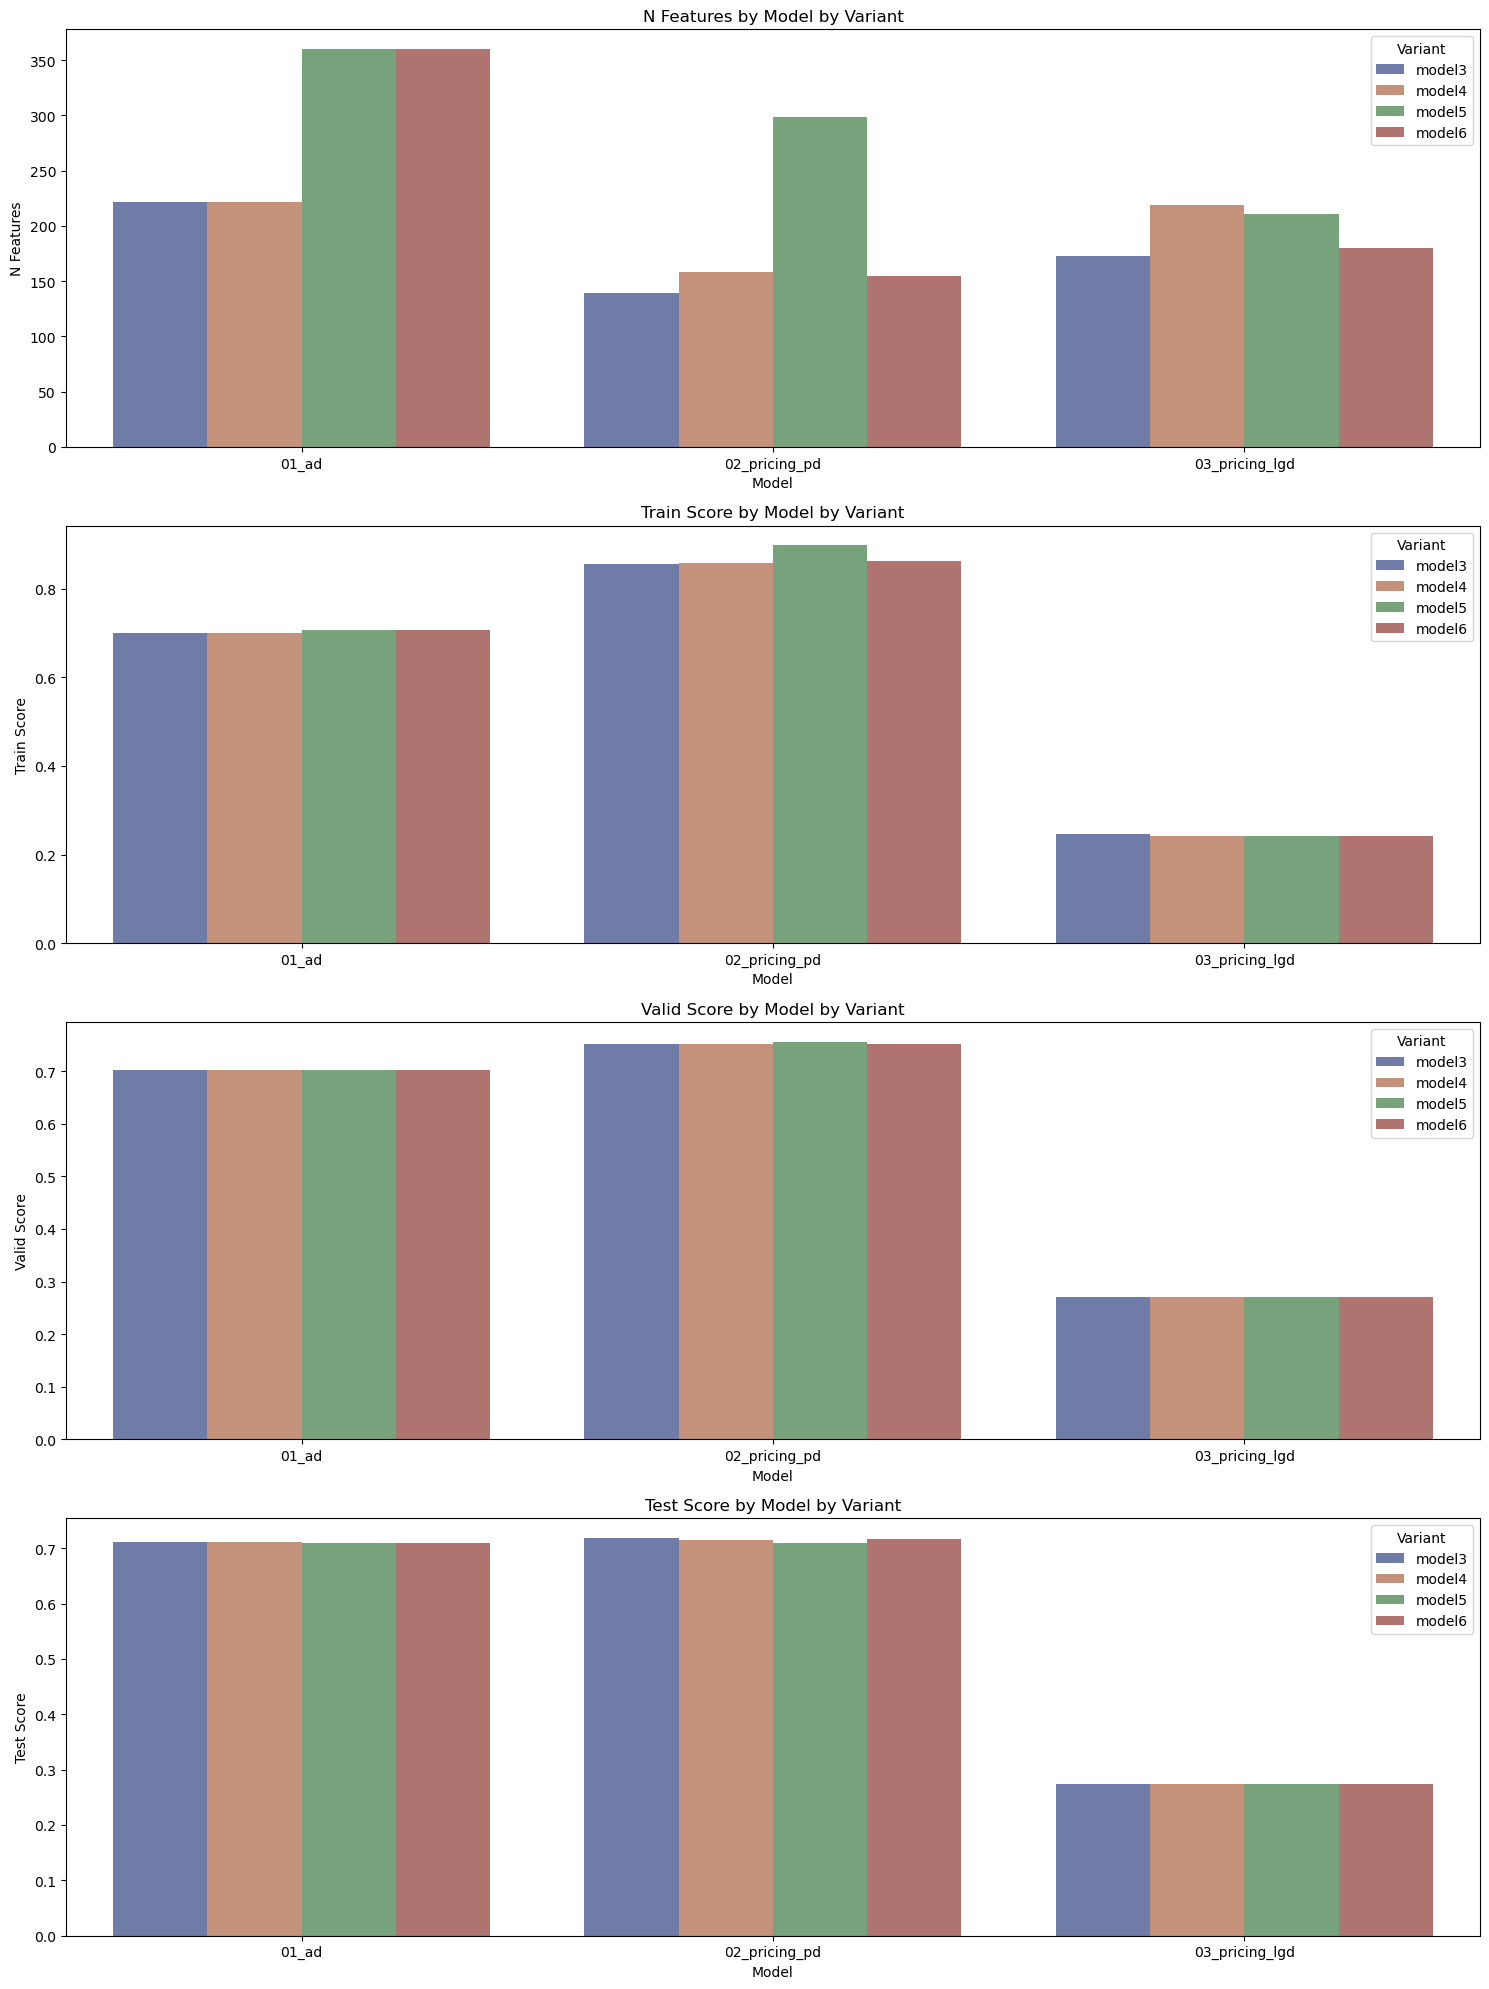

In [39]:
list_str_value = [
    'N Features',
    'Train Score',
    'Valid Score',
    'Test Score',
]

fig, ax = plt.subplots(nrows=len(list_str_value), figsize=(15, 5*len(list_str_value)))
for a, str_value in enumerate(list_str_value):
    # plot
    sns.barplot(
        data=df, 
        x='Model', 
        y=str_value, 
        hue='Variant',
        palette='dark', 
        alpha=.6, 
        ax=ax[a],
    )
    str_title = f'{str_value} by Model by Variant'
    ax[a].set_title(str_title)

# fix overlap
plt.tight_layout()
# save
str_filename = 'plt_variants.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')
# show
plt.show()